# TransUNet — Chest X-ray Lung Segmentation
## 흉부 X-ray 폐 분할 학습 파이프라인

| 항목 | 내용 |
|------|------|
| 모델 | TransUNet (R50-ViT-B_16) |
| 데이터셋 | Montgomery & Shenzhen Chest X-ray |
| 입력 | `[3, 512, 512]` (grayscale → pseudo-RGB) |
| 출력 | Binary mask (배경 / 폐) |
| GPU | NVIDIA RTX 3060 Ti (8GB) + CUDA 12.6 |

**실행 순서**: 셀을 위에서 아래로 순서대로 실행하세요.  
**주의**: Section 1의 설치 셀은 처음 1회만 실행하면 됩니다.

---
## Section 1. 패키지 설치
> 처음 실행 시에만 실행하세요. 설치 완료 후 커널을 재시작(Restart Kernel)하세요.

In [1]:
# # ─── Step 1-1: PyTorch 설치 (CUDA 12.6 → cu124 빌드 사용) ───────────────────
# # 이미 설치되어 있다면 이 셀을 건너뛰세요.
# # 손상된 설치가 있다면 먼저 아래 주석을 해제하고 제거 후 재설치하세요.

!pip uninstall torch torchvision torchaudio -y  # 손상된 기존 설치 제거

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q
print("✓ PyTorch 설치 완료")

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


✓ PyTorch 설치 완료


In [3]:
# ─── Step 1-2: 나머지 의존 패키지 설치 ──────────────────────────────────────
!pip install \
    ml-collections \
    tensorboardX \
    medpy \
    SimpleITK \
    -q

print("✓ 추가 패키지 설치 완료")

✓ 추가 패키지 설치 완료


In [1]:
# ─── Step 1-3: 설치 결과 확인 ───────────────────────────────────────────────
import importlib

required = [
    "torch", "torchvision", "numpy", "PIL", "scipy",
    "tqdm", "tensorboard", "tensorboardX",
    "ml_collections", "medpy", "SimpleITK", "h5py"
]

all_ok = True
for pkg in required:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'n/a')
        print(f"  ✓  {pkg:<18} {ver}")
    except ImportError:
        print(f"  ✗  {pkg:<18} ← 설치 필요")
        all_ok = False

print()
if all_ok:
    print("✅ 모든 패키지 확인 완료 — Section 2로 진행하세요.")
else:
    print("❌ 누락된 패키지가 있습니다. 위 셀을 다시 실행하세요.")

: 

---
## Section 2. 환경 초기화 및 설정

In [ ]:
# ─── Step 2-1: 라이브러리 임포트 ─────────────────────────────────────────────
import os
import sys
import random
import logging
from glob import glob

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader
from torch.nn.modules.loss import CrossEntropyLoss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
from PIL import Image

# ─── TransUNet 모듈 경로 추가 ────────────────────────────────────────────────
# 이 노트북은 TransUNet/ 폴더 안에 있으므로 현재 경로를 sys.path에 추가
TRANSUNET_ROOT = os.path.dirname(os.path.abspath("."))
if TRANSUNET_ROOT not in sys.path:
    sys.path.insert(0, TRANSUNET_ROOT)

# 현재 디렉토리가 TransUNet/ 인지 확인
CWD = os.getcwd()
if not CWD.endswith('TransUNet'):
    os.chdir('TransUNet')  # TransUNet/ 폴더로 이동

print(f"작업 디렉토리: {os.getcwd()}")
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

작업 디렉토리: c:\Users\user\Desktop\Code\vscode\segmentation-beta\TransUNet
Python   : 3.11.15
PyTorch  : 2.7.1+cu118
CUDA 사용 가능: True
GPU      : NVIDIA GeForce RTX 3060 Ti
VRAM     : 8.0 GB


: 

: 

In [ ]:
# ─── Step 2-2: 설정값 (CONFIG) ───────────────────────────────────────────────
# 여기서 모든 실험 파라미터를 한 곳에서 관리합니다.

class CFG:
    # ── 데이터 경로
    ROOT_PATH = "../data/Chest Xray Masks and Labels/data/Lung Segmentation"

    # ── 모델
    VIT_NAME        = "R50-ViT-B_16"  # 사용할 ViT 아키텍처
    PRETRAINED_PATH = "../model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz"
    N_SKIP          = 3               # skip connection 개수
    NUM_CLASSES     = 2               # 배경(0), 폐(1)

    # ── 입력
    IMG_SIZE        = 512             # 입력 해상도 (H=W)
    PATCH_SIZE      = 16              # ViT 패치 크기 → grid=(32,32)

    # ── 학습
    BATCH_SIZE      = 8               # VRAM 부족 시 4로 줄이세요
    MAX_EPOCHS      = 150
    BASE_LR         = 0.01
    TRAIN_RATIO     = 0.7             # 학습:검증:테스트 = 70:15:15
    VAL_RATIO       = 0.15            # 검증 비율
    NUM_WORKERS     = 4               # Windows: 0 권장 (멀티프로세싱 이슈)
    USE_AMP         = True            # Automatic Mixed Precision (RTX 3060 Ti 지원)
    SAVE_INTERVAL   = 10              # N 에폭마다 체크포인트 저장

    # ── 재현성
    SEED            = 1234

    # ── 출력
    OUTPUT_DIR      = "../model"

# 스냅샷 경로 자동 생성
CFG.SNAPSHOT_PATH = os.path.join(
    CFG.OUTPUT_DIR,
    f"TU_ChestXray_{CFG.IMG_SIZE}",
    f"TU_{CFG.VIT_NAME}_skip{CFG.N_SKIP}_bs{CFG.BATCH_SIZE}_lr{CFG.BASE_LR}_{CFG.IMG_SIZE}"
    + ("_amp" if CFG.USE_AMP else "")
)
os.makedirs(CFG.SNAPSHOT_PATH, exist_ok=True)

print("설정 완료:")
print(f"  데이터 경로  : {CFG.ROOT_PATH}")
print(f"  모델        : {CFG.VIT_NAME}")
print(f"  입력 크기    : {CFG.IMG_SIZE}×{CFG.IMG_SIZE}")
print(f"  배치 크기    : {CFG.BATCH_SIZE}")
print(f"  에폭 수      : {CFG.MAX_EPOCHS}")
print(f"  AMP 사용     : {CFG.USE_AMP}")
print(f"  스냅샷 경로  : {CFG.SNAPSHOT_PATH}")

설정 완료:
  데이터 경로  : ../data/Chest Xray Masks and Labels/data/Lung Segmentation
  모델        : R50-ViT-B_16
  입력 크기    : 512×512
  배치 크기    : 8
  에폭 수      : 150
  AMP 사용     : True
  스냅샷 경로  : ../model\TU_ChestXray_512\TU_R50-ViT-B_16_skip3_bs8_lr0.01_512_amp


: 

: 

In [ ]:
# ─── Step 2-3: 랜덤 시드 고정 (실험 재현성) ─────────────────────────────────
random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
torch.cuda.manual_seed(CFG.SEED)
torch.backends.cudnn.benchmark    = False  # 재현성 우선
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ 시드 고정 완료 (seed={CFG.SEED})")
print(f"✓ 연산 디바이스: {DEVICE}")

✓ 시드 고정 완료 (seed=1234)
✓ 연산 디바이스: cuda


: 

: 

---
## Section 3. 데이터셋 검증 및 시각화

In [ ]:
# ─── Step 3-1: 데이터셋 경로 확인 ──────────────────────────────────────────
cxr_dir  = os.path.join(CFG.ROOT_PATH, 'CXR_png')
mask_dir = os.path.join(CFG.ROOT_PATH, 'masks')

img_files  = sorted(glob(os.path.join(cxr_dir, '*.png')))
mask_files = sorted(glob(os.path.join(mask_dir, '*.png')))

print(f"CXR 이미지 수    : {len(img_files)}")
print(f"마스크 파일 수    : {len(mask_files)}")

# 매칭 가능한 쌍 확인
matched = []
for img_path in img_files:
    name      = os.path.basename(img_path)
    mask_path = os.path.join(mask_dir, name.replace('.png', '_mask.png'))
    if os.path.exists(mask_path):
        matched.append((img_path, mask_path))

n_train = int(len(matched) * CFG.TRAIN_RATIO)
n_val   = len(matched) - n_train

print(f"매칭된 이미지-마스크 쌍: {len(matched)}")
print(f"  → 학습 샘플: {n_train}")
print(f"  → 검증 샘플: {n_val}")

assert len(matched) > 0, "매칭된 샘플이 없습니다. 경로를 확인하세요."

CXR 이미지 수    : 800
마스크 파일 수    : 704
매칭된 이미지-마스크 쌍: 566
  → 학습 샘플: 452
  → 검증 샘플: 114


: 

: 

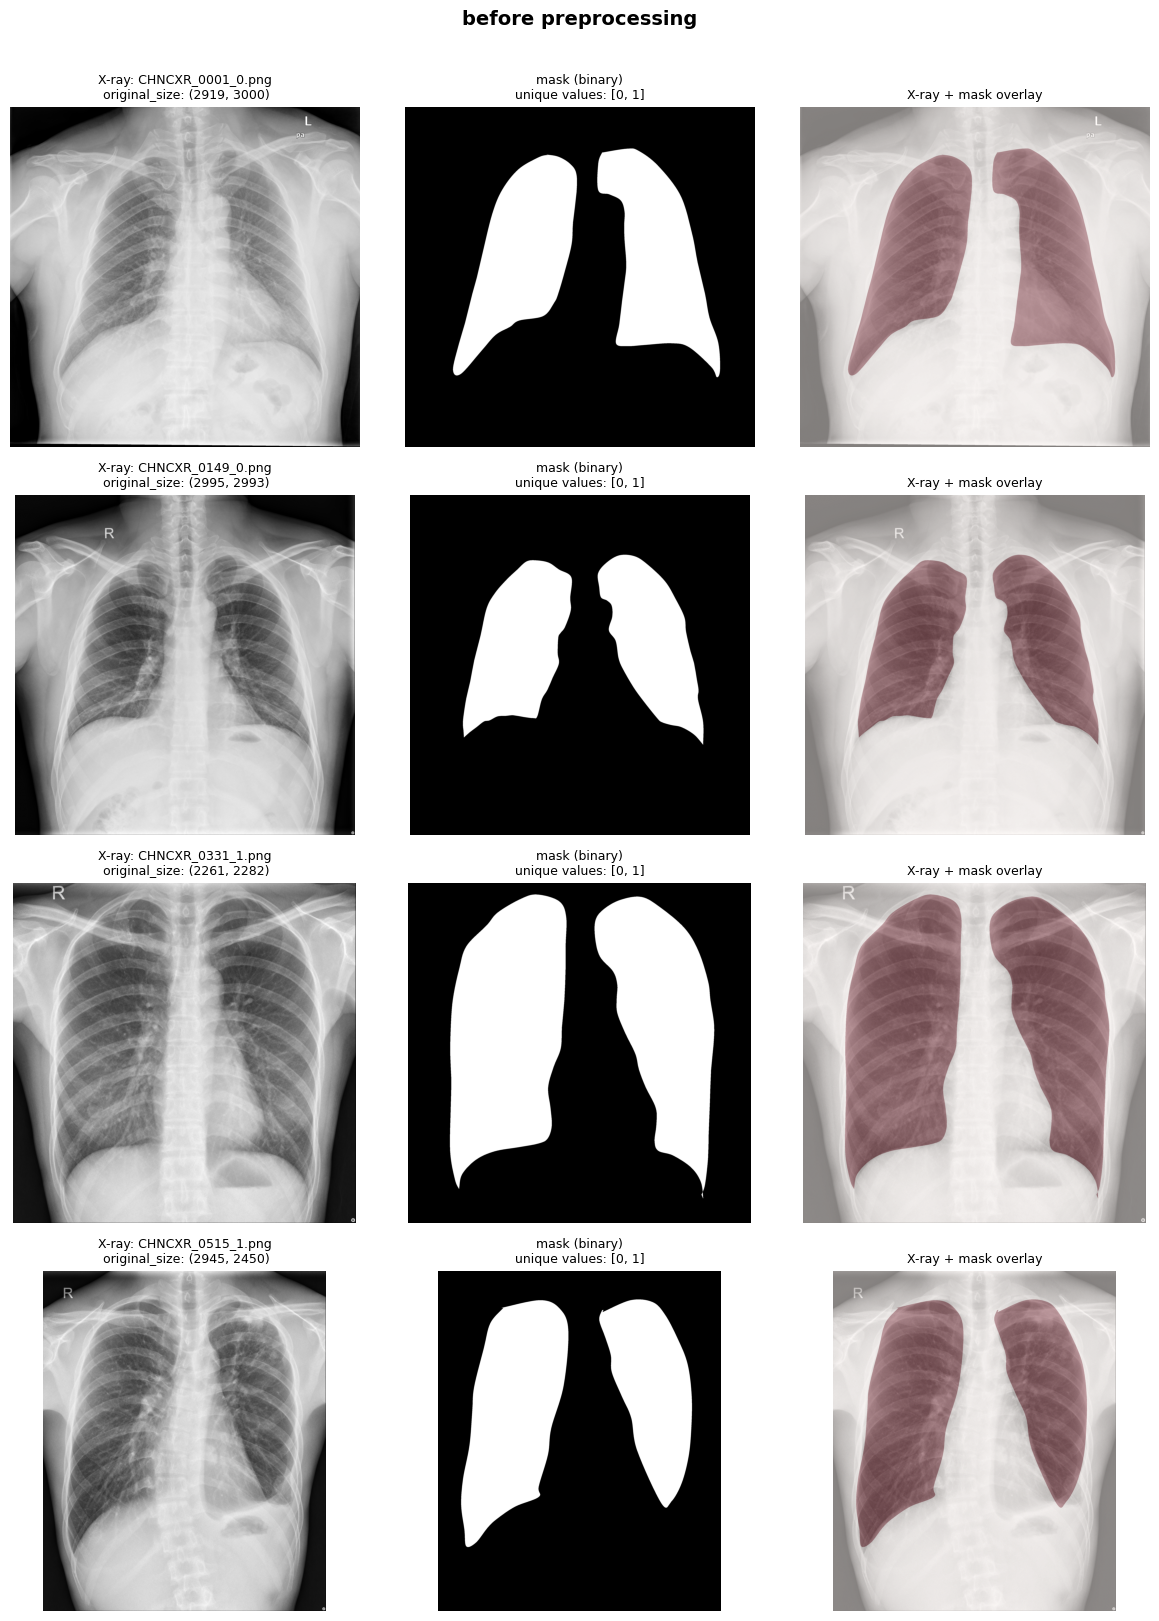

Visualization saved: sample_visualization.png


: 

: 

In [ ]:
# ─── Step 3-2: 원본 이미지/마스크 시각화 (전처리 전) ──────────────────────
sample_indices = [0, len(matched)//4, len(matched)//2, len(matched)*3//4]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))
fig.suptitle("before preprocessing", fontsize=14, fontweight='bold', y=1.01)

for row, idx in enumerate(sample_indices):
    img_path, mask_path = matched[idx]

    img  = np.array(Image.open(img_path).convert('L'))
    mask = np.array(Image.open(mask_path).convert('L'))
    mask_bin = (mask > 127).astype(np.uint8)

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f"X-ray: {os.path.basename(img_path)}\n original_size: {img.shape}",
                           fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_bin, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f"mask (binary)\nunique values: {np.unique(mask_bin).tolist()}",
                           fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(img, cmap='gray', alpha=0.75)
    axes[row, 2].imshow(mask_bin, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
    axes[row, 2].set_title("X-ray + mask overlay", fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('sample_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Visualization saved: sample_visualization.png")

In [ ]:
# ─── Step 3-3: Dataset & DataLoader 초기화 ──────────────────────────────
from datasets.dataset_custom import ChestXrayDataset, RandomGenerator

train_dataset = ChestXrayDataset(
    data_root   = CFG.ROOT_PATH,
    split       = 'train',
    transform   = RandomGenerator(output_size=[CFG.IMG_SIZE, CFG.IMG_SIZE]),
    train_ratio = CFG.TRAIN_RATIO,
    val_ratio   = CFG.VAL_RATIO
)

val_dataset = ChestXrayDataset(
    data_root   = CFG.ROOT_PATH,
    split       = 'val',
    transform   = RandomGenerator(output_size=[CFG.IMG_SIZE, CFG.IMG_SIZE]),
    train_ratio = CFG.TRAIN_RATIO,
    val_ratio   = CFG.VAL_RATIO
)

test_dataset = ChestXrayDataset(
    data_root   = CFG.ROOT_PATH,
    split       = 'test',
    transform   = RandomGenerator(output_size=[CFG.IMG_SIZE, CFG.IMG_SIZE]),
    train_ratio = CFG.TRAIN_RATIO,
    val_ratio   = CFG.VAL_RATIO
)

def worker_init_fn(worker_id):
    random.seed(CFG.SEED + worker_id)

train_loader = DataLoader(
    train_dataset,
    batch_size       = CFG.BATCH_SIZE,
    shuffle          = True,
    num_workers      = CFG.NUM_WORKERS,
    pin_memory       = True,
    worker_init_fn   = worker_init_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = 1,
    shuffle     = False,
    num_workers = CFG.NUM_WORKERS,
    pin_memory  = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = 1,
    shuffle     = False,
    num_workers = CFG.NUM_WORKERS,
    pin_memory  = True
)

# 텐서 형상 확인
sample_batch = next(iter(train_loader))
print("DataLoader 확인:")
print(f"  이미지 shape : {sample_batch['image'].shape}  ← [B, 3, 512, 512] 이어야 함")
print(f"  마스크 shape : {sample_batch['label'].shape}  ← [B, 512, 512] 이어야 함")
print(f"  이미지 범위  : [{sample_batch['image'].min():.3f}, {sample_batch['image'].max():.3f}]")
print(f"  마스크 값    : {torch.unique(sample_batch['label']).tolist()}")
print()
n_total = len(train_dataset) + len(val_dataset) + len(test_dataset)
print(f"Split summary (total {n_total}):")
print(f"  train : {len(train_dataset)} ({len(train_dataset)/n_total*100:.0f}%)")
print(f"  val   : {len(val_dataset)} ({len(val_dataset)/n_total*100:.0f}%)")
print(f"  test  : {len(test_dataset)} ({len(test_dataset)/n_total*100:.0f}%)")


Loaded 452 train samples from ../data/Chest Xray Masks and Labels/data/Lung Segmentation
Loaded 114 val samples from ../data/Chest Xray Masks and Labels/data/Lung Segmentation


: 

: 

In [ ]:
# ─── Step 3-4: 전처리 후 배치 시각화 ────────────────────────────────────────
imgs   = sample_batch['image']   # [B, 3, 512, 512]
labels = sample_batch['label']   # [B, 512, 512]
names  = sample_batch['case_name']

n_show = min(4, CFG.BATCH_SIZE)
fig, axes = plt.subplots(n_show, 3, figsize=(11, 3.5 * n_show))
fig.suptitle(f"after preprocessing: batch sample ({CFG.IMG_SIZE}×{CFG.IMG_SIZE}, 3-channel)",
             fontsize=13, fontweight='bold')

for i in range(n_show):
    img_np   = imgs[i, 0].numpy()    # 채널 0 (R=G=B이므로 동일)
    label_np = labels[i].numpy()

    axes[i, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"{names[i]}\nchannel 0 (R)", fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(label_np, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"mask (binary)\nlung pixels: {label_np.sum():,}", fontsize=8)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(img_np, cmap='gray', vmin=0, vmax=1, alpha=0.75)
    axes[i, 2].imshow(label_np, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
    axes[i, 2].set_title("overlay", fontsize=8)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

: 

: 

---
## Section 4. 모델 초기화

In [ ]:
# ─── Step 4-1: TransUNet 모델 초기화 ─────────────────────────────────────────
from networks.vit_seg_modeling import VisionTransformer as ViT_seg
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg

config_vit = CONFIGS_ViT_seg[CFG.VIT_NAME]
config_vit.n_classes = CFG.NUM_CLASSES
config_vit.n_skip    = CFG.N_SKIP

# R50 계열: img_size / patch_size로 grid 크기 결정
if 'R50' in CFG.VIT_NAME:
    config_vit.patches.grid = (
        CFG.IMG_SIZE // CFG.PATCH_SIZE,
        CFG.IMG_SIZE // CFG.PATCH_SIZE
    )
    print(f"ViT patch grid: {config_vit.patches.grid}  ({config_vit.patches.grid[0]**2} patches)")

model = ViT_seg(config_vit, img_size=CFG.IMG_SIZE, num_classes=config_vit.n_classes)
model = model.to(DEVICE)

# 파라미터 수 계산
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"all parameters    : {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")

# VRAM 사용량 확인
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM usage (after model loading): {allocated:.2f} GB")

: 

: 

In [ ]:
# ─── Step 4-2: 사전 학습 가중치 로드 ─────────────────────────────────────────
# 가중치 파일이 없으면 스크래치에서 학습합니다.
# 다운로드 링크: https://console.cloud.google.com/storage/vit_models/
#   → imagenet21k/R50+ViT-B_16.npz 를 ../model/vit_checkpoint/imagenet21k/ 에 저장

if os.path.exists(CFG.PRETRAINED_PATH):
    model.load_from(weights=np.load(CFG.PRETRAINED_PATH))
    print(f"completed loading pre-trained weights: {CFG.PRETRAINED_PATH}")
else:
    print(f"No pre-trained weights found: {CFG.PRETRAINED_PATH}")
    print("   → Starting training with random initialization.")
    print("   → Downloading weights is recommended (significant difference in convergence speed)")

: 

: 

---
## Section 5. 손실 함수 · 옵티마이저 · AMP 설정

In [ ]:
from utils import DiceLoss

# ─── 손실 함수: 0.5 × CrossEntropy + 0.5 × Dice ─────────────────────────────
ce_loss   = CrossEntropyLoss()
dice_loss = DiceLoss(CFG.NUM_CLASSES)

# ─── 옵티마이저: SGD + Momentum ────────────────────────────────────────────
optimizer = optim.SGD(
    model.parameters(),
    lr           = CFG.BASE_LR,
    momentum     = 0.9,
    weight_decay = 1e-4
)

# ─── AMP GradScaler ────────────────────────────────────────────────────────
scaler = GradScaler() if CFG.USE_AMP else None

max_iterations = CFG.MAX_EPOCHS * len(train_loader)

print(f"손실 함수  : 0.5 × CE  +  0.5 × Dice")
print(f"옵티마이저 : SGD (lr={CFG.BASE_LR}, momentum=0.9, wd=1e-4)")
print(f"AMP        : {CFG.USE_AMP}")
print(f"배치 수/에폭: {len(train_loader)}")
print(f"총 iteration: {max_iterations:,}")

: 

: 

---
## Section 6. 학습 함수 정의

In [ ]:
def calculate_dice_score(pred, target, num_classes=2):
    """배치 단위 Dice Score 계산 (배경 클래스 제외)"""
    dice_scores = []
    pred_np   = pred.cpu().numpy()
    target_np = target.cpu().numpy()

    for cls in range(1, num_classes):   # class 0 (배경) 제외
        p = (pred_np   == cls).astype(np.float32)
        t = (target_np == cls).astype(np.float32)

        intersection = (p * t).sum()
        union        = p.sum() + t.sum()

        dice = (2.0 * intersection) / (union + 1e-7) if union > 0 else 1.0
        dice_scores.append(dice)

    return float(np.mean(dice_scores)) if dice_scores else 0.0


def validate_epoch(model, loader, num_classes, use_amp):
    """검증 에폭 실행 → 평균 Dice Score 반환"""
    model.eval()
    dice_list = []

    with torch.no_grad():
        for batch in loader:
            imgs   = batch['image'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            if use_amp:
                with autocast():
                    outputs = model(imgs)
            else:
                outputs = model(imgs)

            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
            dice_list.append(calculate_dice_score(preds, labels, num_classes))

    model.train()
    return float(np.mean(dice_list))


print("✓ 학습 유틸리티 함수 정의 완료")

: 

: 

---
## Section 7. 학습 실행
> **시간이 오래 걸립니다.** 학습 진행 상황은 아래 tqdm 바와 에폭 로그로 확인하세요.  
> TensorBoard 모니터링: 새 터미널에서 `tensorboard --logdir ../model` 실행

In [ ]:
from tensorboardX import SummaryWriter

# ─── 로거 설정 ─────────────────────────────────────────────────────────────
log_file = os.path.join(CFG.SNAPSHOT_PATH, 'train_log.txt')
logging.basicConfig(
    filename = log_file,
    level    = logging.INFO,
    format   = '[%(asctime)s] %(message)s',
    datefmt  = '%H:%M:%S'
)
logger = logging.getLogger()
logger.addHandler(logging.StreamHandler(sys.stdout))

writer = SummaryWriter(os.path.join(CFG.SNAPSHOT_PATH, 'log'))

# ─── 학습 이력 기록용 리스트 ────────────────────────────────────────────────
history = {
    'train_loss': [],
    'val_dice'  : [],
    'lr'        : []
}

best_dice  = 0.0
iter_num   = 0

model.train()
epoch_pbar = tqdm(range(CFG.MAX_EPOCHS), desc="Epoch", unit="epoch")

for epoch in epoch_pbar:
    epoch_loss = 0.0

    for batch in train_loader:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        # ── Forward + Loss ──────────────────────────────────────────────────
        if CFG.USE_AMP:
            with autocast():
                outputs    = model(imgs)
                loss_ce    = ce_loss(outputs, labels.long())
                loss_dice  = dice_loss(outputs, labels, softmax=True)
                loss       = 0.5 * loss_ce + 0.5 * loss_dice

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs    = model(imgs)
            loss_ce    = ce_loss(outputs, labels.long())
            loss_dice  = dice_loss(outputs, labels, softmax=True)
            loss       = 0.5 * loss_ce + 0.5 * loss_dice

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ── Polynomial LR Decay ─────────────────────────────────────────────
        lr_now = CFG.BASE_LR * (1.0 - iter_num / max_iterations) ** 0.9
        for pg in optimizer.param_groups:
            pg['lr'] = lr_now

        iter_num   += 1
        epoch_loss += loss.item()

        writer.add_scalar('train/loss',    loss.item(), iter_num)
        writer.add_scalar('train/loss_ce', loss_ce.item(), iter_num)
        writer.add_scalar('train/lr',      lr_now, iter_num)

    # ── Validation ─────────────────────────────────────────────────────────
    avg_loss = epoch_loss / len(train_loader)
    avg_dice = validate_epoch(model, val_loader, CFG.NUM_CLASSES, CFG.USE_AMP)

    writer.add_scalar('val/dice_score', avg_dice, epoch)
    history['train_loss'].append(avg_loss)
    history['val_dice'].append(avg_dice)
    history['lr'].append(lr_now)

    epoch_pbar.set_postfix({
        'loss': f'{avg_loss:.4f}',
        'val_dice': f'{avg_dice:.4f}',
        'best': f'{best_dice:.4f}'
    })

    logger.info(
        f"Epoch [{epoch+1:03d}/{CFG.MAX_EPOCHS}]  "
        f"loss={avg_loss:.4f}  val_dice={avg_dice:.4f}  "
        f"lr={lr_now:.6f}  best={best_dice:.4f}"
    )

    # ── Best Model 저장 ─────────────────────────────────────────────────────
    if avg_dice > best_dice:
        best_dice = avg_dice
        best_path = os.path.join(CFG.SNAPSHOT_PATH, 'best_model.pth')
        torch.save(model.state_dict(), best_path)
        logger.info(f"  → Best model saved (dice={best_dice:.4f})")

    # ── 체크포인트 저장 ─────────────────────────────────────────────────────
    if (epoch + 1) % CFG.SAVE_INTERVAL == 0:
        ckpt_path = os.path.join(CFG.SNAPSHOT_PATH, f'epoch_{epoch}.pth')
        torch.save(model.state_dict(), ckpt_path)

writer.close()
print(f"\n🏁 학습 완료 — Best Validation Dice: {best_dice:.4f}")
print(f"   Best model: {os.path.join(CFG.SNAPSHOT_PATH, 'best_model.pth')}")

: 

: 

---
## Section 8. 학습 결과 시각화

In [ ]:
# ─── Step 8-1: Loss / Dice Score 학습 곡선 ───────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("training results", fontsize=14, fontweight='bold')

# Training Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', linewidth=1.5)
axes[0].set_title("Training Loss (0.5×CE + 0.5×Dice)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# Validation Dice Score
axes[1].plot(epochs_range, history['val_dice'], 'g-', linewidth=1.5)
axes[1].axhline(y=best_dice, color='r', linestyle='--',
                label=f'Best: {best_dice:.4f}', linewidth=1)
axes[1].set_title("Validation Dice Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate Schedule
axes[2].plot(epochs_range, history['lr'], 'orange', linewidth=1.5)
axes[2].set_title("Learning Rate (Polynomial Decay)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG.SNAPSHOT_PATH, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"training curves saved")

: 

: 

In [ ]:
# ─── Step 8-2: Best Model로 검증 셋 예측 시각화 ─────────────────────────────
best_path = os.path.join(CFG.SNAPSHOT_PATH, 'best_model.pth')

# Best Model 로드
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

# 검증 셋에서 4개 샘플 시각화
val_samples = []
with torch.no_grad():
    for i, batch in enumerate(val_loader):
        if i >= 4:
            break
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        if CFG.USE_AMP:
            with autocast():
                outputs = model(imgs)
        else:
            outputs = model(imgs)

        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        dice  = calculate_dice_score(preds, labels, CFG.NUM_CLASSES)

        val_samples.append({
            'img'  : imgs[0, 0].cpu().numpy(),
            'label': labels[0].cpu().numpy(),
            'pred' : preds[0].cpu().numpy(),
            'dice' : dice,
            'name' : batch['case_name'][0]
        })

# 시각화
n = len(val_samples)
fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
fig.suptitle(f"Best Model prediction results (Best Dice: {best_dice:.4f})",
             fontsize=13, fontweight='bold')

col_titles = ["Input X-ray", "Ground Truth", "Prediction", "Overlay (GT=Red / Pred=Blue)"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

for i, s in enumerate(val_samples):
    img, gt, pred = s['img'], s['label'], s['pred']

    axes[i, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_ylabel(f"{s['name']}\nDice={s['dice']:.4f}", fontsize=8)

    axes[i, 1].imshow(gt,   cmap='gray', vmin=0, vmax=1)
    axes[i, 2].imshow(pred, cmap='gray', vmin=0, vmax=1)

    # 오버레이: GT(Red) + Pred(Blue)
    overlay = np.stack([img]*3, axis=-1)  # RGB로 확장
    overlay[gt   == 1, 0] = 0.9           # GT → Red 채널
    overlay[pred == 1, 2] = 0.9           # Pred → Blue 채널
    axes[i, 3].imshow(np.clip(overlay, 0, 1))

    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CFG.SNAPSHOT_PATH, 'prediction_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print("prediction results visualization saved")

: 

: 

In [ ]:
# ─── Step 8-3: 전체 검증 셋 최종 Dice Score 계산 ────────────────────────────
all_dice = []

model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="final evaluation"):
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        if CFG.USE_AMP:
            with autocast():
                outputs = model(imgs)
        else:
            outputs = model(imgs)

        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        all_dice.append(calculate_dice_score(preds, labels, CFG.NUM_CLASSES))

final_dice = np.mean(all_dice)
print("\n" + "="*45)
print(f"  final validation Dice Score : {final_dice:.4f}")
print(f"  Best Dice Score      : {best_dice:.4f}")
print(f"  validation sample count : {len(val_dataset)}")
print("="*45)
print(f"\n  result saved at: {CFG.SNAPSHOT_PATH}")

: 

: 

---
## Section 9. 학습된 모델 저장 및 경로 정리

In [ ]:
# ─── Step 9-1: 생성된 파일 목록 ─────────────────────────────────────────────
print("list of generated files:")
for root, dirs, files in os.walk(CFG.SNAPSHOT_PATH):
    level = root.replace(CFG.SNAPSHOT_PATH, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size  = os.path.getsize(fpath) / 1024**2
        print(f"{indent}  {f:40s} {size:.1f} MB")

: 

: 

In [ ]:
# ─── Step 9-2: Final Evaluation — DSC / IoU / HD95 ────────────────────────
from medpy.metric.binary import hd95 as medpy_hd95

def calculate_metrics(pred, target, num_classes=2):
    """Compute DSC, IoU, HD95 for a single batch (background excluded)."""
    pred_np   = pred.cpu().numpy()
    target_np = target.cpu().numpy()
    dsc_list, iou_list, hd95_list = [], [], []

    for cls in range(1, num_classes):
        p = (pred_np   == cls).astype(np.uint8)
        t = (target_np == cls).astype(np.uint8)

        intersection = (p * t).sum()
        p_sum, t_sum = p.sum(), t.sum()
        union_dt     = p_sum + t_sum

        # DSC (F1)
        dsc = (2.0 * intersection) / (union_dt + 1e-7) if union_dt > 0 else 1.0
        dsc_list.append(dsc)

        # IoU (Jaccard)
        iou_denom = union_dt - intersection
        iou = intersection / (iou_denom + 1e-7) if iou_denom > 0 else 1.0
        iou_list.append(iou)

        # HD95 (requires both pred and GT to have foreground pixels)
        if p.sum() > 0 and t.sum() > 0:
            hd = float(medpy_hd95(p, t))
        elif p.sum() == 0 and t.sum() == 0:
            hd = 0.0   # both empty → perfect
        else:
            hd = float(max(p.shape))  # worst case: missed/false positive
        hd95_list.append(hd)

    return {
        'dsc' : float(np.mean(dsc_list)),
        'iou' : float(np.mean(iou_list)),
        'hd95': float(np.mean(hd95_list)),
    }


# ── Run full validation set evaluation ────────────────────────────────────
model.load_state_dict(torch.load(os.path.join(CFG.SNAPSHOT_PATH, 'best_model.pth'), map_location=DEVICE))
model.eval()

all_dsc, all_iou, all_hd95 = [], [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Test Evaluation"):
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        if CFG.USE_AMP:
            with autocast():
                outputs = model(imgs)
        else:
            outputs = model(imgs)

        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        m = calculate_metrics(preds, labels, CFG.NUM_CLASSES)
        all_dsc.append(m['dsc'])
        all_iou.append(m['iou'])
        all_hd95.append(m['hd95'])

print()
print("=" * 50)
print(f"  Validation samples       : {len(test_dataset)}")
print("-" * 50)
print(f"  DSC  (Dice / F1)         : {np.mean(all_dsc):.4f}  ± {np.std(all_dsc):.4f}")
print(f"  IoU  (Jaccard Index)     : {np.mean(all_iou):.4f}  ± {np.std(all_iou):.4f}")
print(f"  HD95 (95th Hausdorff)    : {np.mean(all_hd95):.2f} px ± {np.std(all_hd95):.2f}")
print("=" * 50)
